In [22]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
import os

# Set your dataset path
BASE_DIR = '/content/drive/MyDrive/FruitinAmazon'
train_dir = os.path.join(BASE_DIR, 'train')
test_dir  = os.path.join(BASE_DIR, 'test')

print(os.listdir(train_dir))

['.DS_Store', 'tucuma', 'cupuacu', 'guarana', 'acai', 'pupunha', 'graviola']


Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


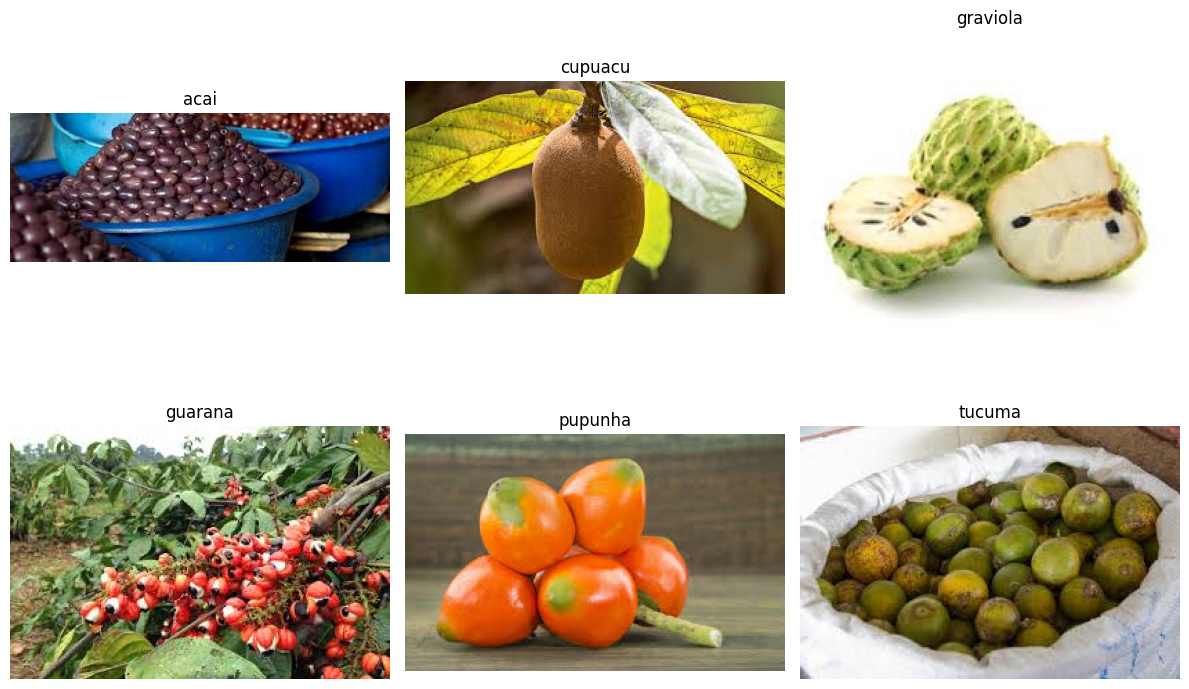

In [24]:
# Task 1.1 - Visualize one random image per class in a 2-row grid
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

class_dirs = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
print("Classes:", class_dirs)

sample_images = []
for cls in class_dirs:
    cls_path = os.path.join(train_dir, cls)
    images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    chosen = random.choice(images)
    sample_images.append((cls, os.path.join(cls_path, chosen)))

cols = (len(class_dirs) + 1) // 2
fig, axes = plt.subplots(2, cols, figsize=(cols * 4, 8))
axes = axes.flatten()

for i, (cls_name, img_path) in enumerate(sample_images):
    img = mpimg.imread(img_path)
    axes[i].imshow(img)
    axes[i].set_title(cls_name)
    axes[i].axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [25]:
# Task 1.2 - Check for corrupted images
from PIL import Image

corrupted = []

for cls in class_dirs:
    cls_path = os.path.join(train_dir, cls)
    for img_file in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_file)
        try:
            with Image.open(img_path) as img:
                img.verify()
        except (IOError, SyntaxError):
            corrupted.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

if not corrupted:
    print("No Corrupted Images Found.")

No Corrupted Images Found.


Task 2

In [26]:
import tensorflow as tf

img_height       = 128
img_width        = 128
batch_size       = 32
validation_split = 0.2

rescale = tf.keras.layers.Rescaling(1./255)

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir, labels='inferred', label_mode='int',
    image_size=(img_height, img_width), interpolation='nearest',
    batch_size=batch_size, shuffle=True,
    validation_split=validation_split, subset='training', seed=123
)
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir, labels='inferred', label_mode='int',
    image_size=(img_height, img_width), interpolation='nearest',
    batch_size=batch_size, shuffle=False,
    validation_split=validation_split, subset='validation', seed=123
)
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir, labels='inferred', label_mode='int',
    image_size=(img_height, img_width), interpolation='nearest',
    batch_size=batch_size, shuffle=False
)
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

class_names = class_dirs
num_classes = len(class_names)
print("Classes:", class_names)
print("Num classes:", num_classes)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Num classes: 6


Task 3: Build the CNN

In [27]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), padding='same', strides=1, activation='relu', input_shape=(img_height, img_width, 3)),
    layers.MaxPooling2D((2,2), strides=2),

    layers.Conv2D(32, (3,3), padding='same', strides=1, activation='relu'),
    layers.MaxPooling2D((2,2), strides=2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(64,  activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,222 (16.07 MB)

 Trainable params: 4,213,222 (16.07 MB)

 Non-trainable params: 0 (0.00 B)

Task4: Compile and Train

In [28]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [29]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint_cb = ModelCheckpoint('best_fruit_model.h5', monitor='val_accuracy', save_best_only=True, verbose=1)
early_stop_cb = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)

history = model.fit(
    train_ds,
    epochs=250,
    batch_size=16,
    validation_data=val_ds,
    callbacks=[checkpoint_cb, early_stop_cb]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.1545 - loss: 2.0046
Epoch 1: val_accuracy improved from None to 0.05556, saving model to best_fruit_model.h5



Epoch 1: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 635ms/step - accuracy: 0.1667 - loss: 2.1161 - val_accuracy: 0.0556 - val_loss: 1.3079
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - accuracy: 0.1505 - loss: 2.1507
Epoch 2: val_accuracy improved from 0.05556 to 0.22222, saving model to best_fruit_model.h5



Epoch 2: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 612ms/step - accuracy: 0.1389 - loss: 2.0977 - val_accuracy: 0.2222 - val_loss: 1.6847
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step - accuracy: 0.3675 - loss: 1.5773
Epoch 3: val_accuracy did not improve from 0.22222
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 535ms/step - accuracy: 0.4306 - loss: 1.5518 - val_accuracy: 0.1667 - val_loss: 1.6073
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.4236 - loss: 1.4033
Epoch 4: val_accuracy did not improve from 0.22222
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 446ms/step - accuracy: 0.4583 - loss: 1.3774 - val_accuracy: 0.2222 - val_loss: 1.5599
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 608ms/step - accuracy: 0.4427 - loss: 1.2054
Epoch 5: val_accuracy improved from 0.22222 to 0.27778, saving model to best_fruit_model.h5



Epoch 5: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 853ms/step - accuracy: 0.5000 - loss: 1.1833 - val_accuracy: 0.2778 - val_loss: 1.4292
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 566ms/step - accuracy: 0.7703 - loss: 0.9809
Epoch 6: val_accuracy improved from 0.27778 to 0.61111, saving model to best_fruit_model.h5



Epoch 6: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 756ms/step - accuracy: 0.7639 - loss: 0.9634 - val_accuracy: 0.6111 - val_loss: 1.4032
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 0.8958 - loss: 0.7370
Epoch 7: val_accuracy improved from 0.61111 to 0.66667, saving model to best_fruit_model.h5



Epoch 7: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 523ms/step - accuracy: 0.8750 - loss: 0.7670 - val_accuracy: 0.6667 - val_loss: 1.1989
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - accuracy: 0.8860 - loss: 0.5547
Epoch 8: val_accuracy improved from 0.66667 to 0.72222, saving model to best_fruit_model.h5



Epoch 8: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 592ms/step - accuracy: 0.8611 - loss: 0.5796 - val_accuracy: 0.7222 - val_loss: 0.9839
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - accuracy: 0.9062 - loss: 0.3776
Epoch 9: val_accuracy improved from 0.72222 to 0.88889, saving model to best_fruit_model.h5



Epoch 9: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 526ms/step - accuracy: 0.8750 - loss: 0.4207 - val_accuracy: 0.8889 - val_loss: 0.7109
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step - accuracy: 0.9705 - loss: 0.2540
Epoch 10: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 535ms/step - accuracy: 0.9583 - loss: 0.2503 - val_accuracy: 0.4444 - val_loss: 1.1951
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 0.8652 - loss: 0.3093
Epoch 11: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 525ms/step - accuracy: 0.8611 - loss: 0.3080 - val_accuracy: 0.7222 - val_loss: 1.1221
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 594ms/step - accuracy: 0.9902 - loss: 0.1406
Epoch 12: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 727ms/step - accuracy: 0.9861 - loss: 0.1413 - val_accuracy: 0.7222 - val_loss: 0.8813
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 0.9404 

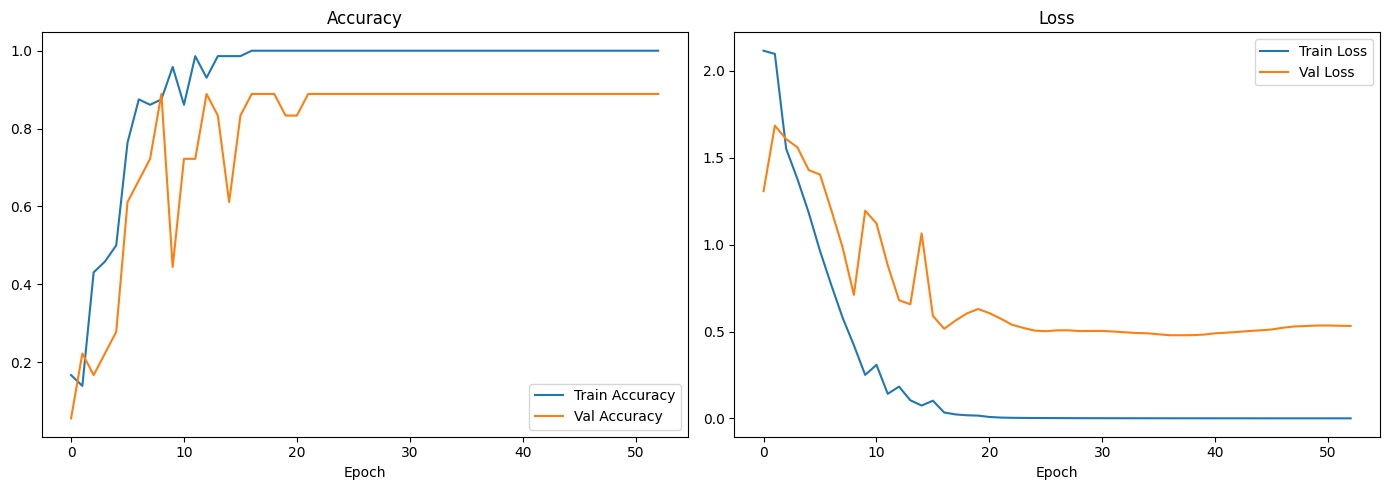

In [30]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

Task5: Evaluate

In [31]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - accuracy: 0.6000 - loss: 1.4472
Test Loss    : 1.4472
Test Accuracy: 0.6000


Task6: Save and Load

In [32]:
model.save('fruit_cnn_model.h5')
print("Model saved.")

loaded_model = tf.keras.models.load_model('fruit_cnn_model.h5')
print("Model loaded.")

loss, acc = loaded_model.evaluate(test_ds)
print(f"Loaded Model - Loss: {loss:.4f} | Accuracy: {acc:.4f}")

Model saved.


Model loaded.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 929ms/step - accuracy: 0.6000 - loss: 1.4472
Loaded Model - Loss: 1.4472 | Accuracy: 0.6000


Task7: Predictions and Classification Report

In [33]:
import numpy as np
from sklearn.metrics import classification_report

y_true, y_pred_probs = [], []

for images, labels in test_ds:
    preds = loaded_model.predict(images, verbose=0)
    y_pred_probs.extend(preds)
    y_true.extend(labels.numpy())

y_pred = np.argmax(np.array(y_pred_probs), axis=1)
y_true = np.array(y_true)

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

        acai       0.67      0.80      0.73         5
     cupuacu       0.75      0.60      0.67         5
    graviola       0.62      1.00      0.77         5
     guarana       0.83      1.00      0.91         5
     pupunha       0.00      0.00      0.00         5
      tucuma       0.20      0.20      0.20         5

    accuracy                           0.60        30
   macro avg       0.51      0.60      0.55        30
weighted avg       0.51      0.60      0.55        30

